In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time 

In [3]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [4]:
with open("../models/IF.pkl","rb") as f :
    iso=pickle.load(f)

with open("../models/AE.pkl","rb") as f :
    ae=pickle.load(f)

with open("../models/SOM.pkl","rb") as f :
    som=pickle.load(f)

c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


ModuleNotFoundError: No module named 'minisom'

In [ ]:
df=pd.read_csv("../data/validation_dataset.csv")
print(df.shape)
df.head()

(1142, 21)


,TransactionID,Time,AccountNumber,CardNumber,TransactionType,Channel,TransactionAmount,MerchandGroup,Country,Country2,...,CardType,Age,Gender,Bank,City,MerchandCode,ClientID,ClientName,IsAnomaly,AnomalyType
0,MON25010081000672,2025-01-01 08:51:27,3973694259,4501140900389113,RETRAIT GAB,ATM,424.35,SUPERMARCHE,MA,MA,...,MASTERCARD_ELITE,47,FEMALE,CDM,OUJDA,SUP_OUJ_614,CLI_008,Khadija Lahlou,0,NORMAL
1,INT25010061000484,2025-01-01 10:32:03,6407369726,4062875514967525,PAIEMENT CARTE,WEB,"1,551.87",HOTEL,MA,MA,...,VISA_PREMIUM,38,FEMALE,CDM,MARRAKECH,HOT_MAR_989,CLI_006,Amina Fassi,0,NORMAL
2,MON25010011000000,2025-01-01 10:39:55,3577090037,4856403845718259,RETRAIT GAB,ATM,424.51,CAFE,MA,MA,...,MASTERCARD_ELITE,45,MALE,CDM,CASABLANCA,CAF_CAS_741,CLI_001,Hassan Benali,0,NORMAL
3,INT25010041000379,2025-01-01 10:56:00,4013818839,4119724022093700,PAIEMENT CARTE,WEB,"6,203.73",SUPERMARCHE,MA,MA,...,MASTERCARD_ELITE,51,FEMALE,CDM,FES,SUP_FES_995,CLI_004,Nadia Chraibi,1,UNUSUAL_HIGH_AMOUNT
4,MON25010101000942,2025-01-01 11:46:00,5454155475,4680020758954956,PAIEMENT CARTE,ATM,251.46,PHARMACIE,MA,MA,...,VISA_GOLD,41,FEMALE,CDM,SETTAT,PHA_SET_457,CLI_010,Souad Benkirane,1,NEW_LOCATION_DOMESTIC


In [ ]:
df.drop(columns=['ClientID','ClientName','AnomalyType'],inplace=True)

In [ ]:
#TransactionID,Time,Account Number,Card Number,Transaction Type,Channel,Transaction Amount,Merchand Group,Country,Country 2,City 2,Card Type,Age,Gender,Bank,City,Merchand Code
columns=["TranasctionID","Time","Account Number","Card Number","Transaction Type","Channel","Transaction Amount","Merchand Group","Country","Country2","City2","Card Type","Age","Gender","Bank",'City','Merchand Code',"isAnomaly"]
df.columns=columns

In [ ]:
from src.features.TimeFeatures import ComputeTimeFeatures
from src.features.CatEntropy import ComputeCatEntropy
from src.features.CatFreq import ComputeCatFreq
from src.preprocessing.PreProcessing import ClientScale
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df.sort_values(['Account Number','Time'],inplace=True)
df['rank']=df.groupby("Account Number")['Time'].rank(method='first',pct=True)

df['Time']=pd.to_datetime(df['Time'])
df['Date']=df['Time'].dt.date
df['Hour']=df['Time'].dt.hour
df['Age']=df['Age'].astype(int)

df['Transaction Amount'] = (
    df['Transaction Amount']
    .astype(str)               
    .str.replace(',', '')      
    .astype(float)
)

In [ ]:
df=ComputeTimeFeatures(df)
df=ComputeCatEntropy(df)
df=ComputeCatFreq(df)

ytrue=df['isAnomaly']
df=df[['Account Number','Age', 'LogAmount','AmountZScore', 'MovingAvg','MovingStd', 'LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']]

df=ClientScale(df,'Account Number',
                    ['LogAmount','AmountZScore', 'MovingAvg','MovingStd', 'LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq'])

df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [ ]:
start=time.time()

isoscore=iso.score(df)

end=time.time()
isotime=end-start
print(isotime)

0.05141901969909668


In [ ]:
start=time.time()

somscore=som.score(df)

end=time.time()
somtime=end-start
print(somtime)

0.057033538818359375


In [ ]:
start=time.time()

aescore=ae.score(df)

end=time.time()
aetime=end-start
print(aetime)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
0.24382543563842773


In [ ]:
df['isoscore']=isoscore
df['aescore']=aescore
df['somscore']=somscore

In [ ]:
df['isoscore'] = MinMaxScaler().fit_transform(df[['isoscore']])
df['aescore']  = MinMaxScaler().fit_transform(df[['aescore']])
df['somscore'] = MinMaxScaler().fit_transform(df[['somscore']])

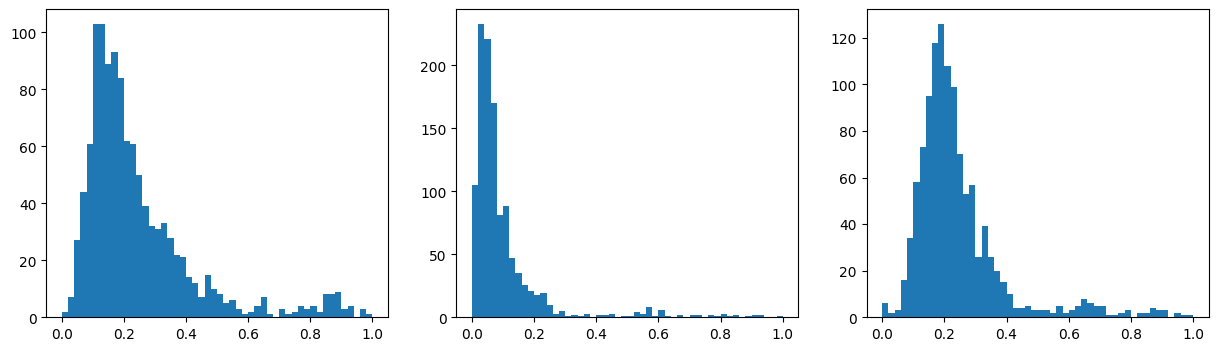

In [ ]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,4))

axes[0].hist(df['isoscore'],bins=50)
axes[1].hist(df['aescore'],bins=50)
axes[2].hist(df['somscore'],bins=50)

plt.show()

In [ ]:
ypred=(df['isoscore']>=0.27).astype(int)

NameError: name 'df' is not defined

In [ ]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

precision = precision_score(ytrue, ypred)
recall = recall_score(ytrue, ypred)
accuracy = accuracy_score(ytrue, ypred)
f1=f1_score(ytrue,ypred)

print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)
print("F1:", f1)

Precision: 0.875
Recall: 0.22727272727272727
Accuracy: 0.7828371278458844
F1: 0.36082474226804123


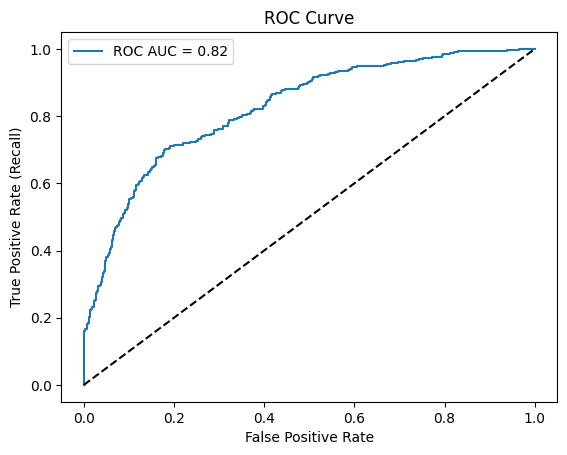

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# y_true: 0=normal, 1=anomaly
# scores: higher = more anomalous

fpr, tpr, thresholds = roc_curve(ytrue, df['isoscore'])
roc_auc = roc_auc_score(ytrue, df['isoscore'])

plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

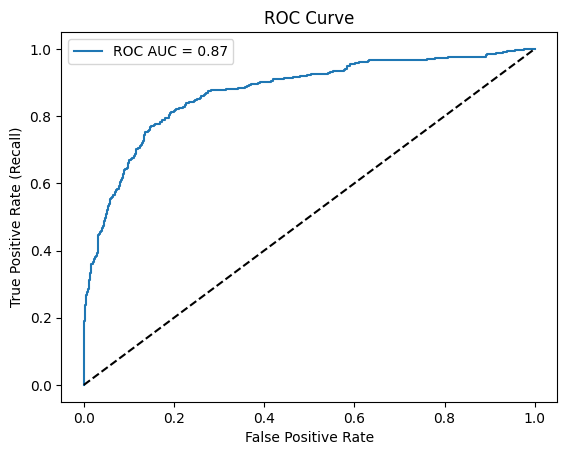

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# y_true: 0=normal, 1=anomaly
# scores: higher = more anomalous

fpr, tpr, thresholds = roc_curve(ytrue, df['aescore'])
roc_auc = roc_auc_score(ytrue, df['aescore'])

plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(ytrue, df['isoscore'])

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold (F1):", best_threshold)

Best threshold (F1): 0.2552316285407725


In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(ytrue, df['isoscore'])

j = tpr - fpr
best_idx = np.argmax(j)

best_threshold = thresholds[best_idx]
print("Best threshold (Youden J):", best_threshold)

Best threshold (Youden J): 0.2515141844313451


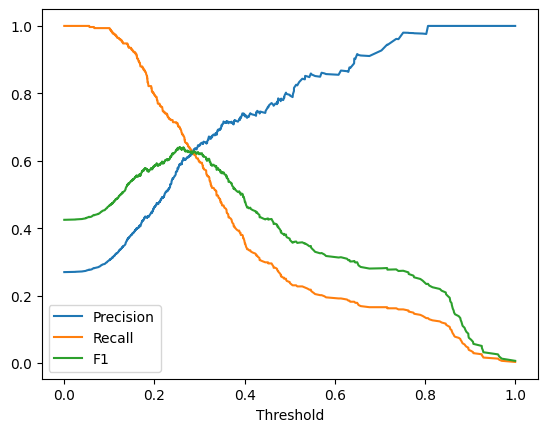

In [ ]:
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1[:-1], label="F1")
plt.legend()
plt.xlabel("Threshold")
plt.show()